# Global Fragility Index

This notebook builds a first-pass **Global Historical Pattern Overlap / Fragility Index** from the historical collapse dataset already developed in this project.

It is **not** a prediction of collapse, **not** a probability model, and **not** a sensational countdown framework. Its purpose is to create a cautious, transparent way to compare present-day global conditions with historically recurrent fragility patterns identified in the historical dataset.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from config import COLLAPSE_DATASET_PATH
from dataset_utils import get_factor_columns, load_collapse_dataset

df = load_collapse_dataset(COLLAPSE_DATASET_PATH)
factor_cols = get_factor_columns()
factor_data = df[factor_cols].apply(pd.to_numeric, errors="coerce")
known_factor_data = factor_data.where(factor_data.isin([0, 1, 2, 3]))

df.shape

(174, 45)

## Part 1 — Modern Global Factor Framework

The factors below are derived from historically strong and comparatively well-supported findings in the collapse dataset. They are slightly renamed where needed for modern global use, but each remains explicitly linked to the historical coding framework.

In [3]:
selected_global_factors = pd.DataFrame(
    [
        {
            "factor_name": "political_fragmentation_polarization",
            "role": "stress",
            "historical_mapping": "political_fragmentation, elite_conflict",
            "reason_for_inclusion": "Historically prominent in higher-collapse and terminal-collapse rows; adapted for a multi-actor global system.",
        },
        {
            "factor_name": "legitimacy_crisis",
            "role": "stress",
            "historical_mapping": "legitimacy_crisis",
            "reason_for_inclusion": "Strong historical differentiator and consistently high in severe decline and collapse rows.",
        },
        {
            "factor_name": "fiscal_strain",
            "role": "stress",
            "historical_mapping": "fiscal_crisis, taxation_extraction_pressure",
            "reason_for_inclusion": "Fiscal stress is one of the clearest historically recurrent weakening dynamics.",
        },
        {
            "factor_name": "trade_disruption",
            "role": "stress",
            "historical_mapping": "trade_disruption",
            "reason_for_inclusion": "Repeatedly associated with severe breakdown, especially in integrated systems.",
        },
        {
            "factor_name": "geopolitical_instability",
            "role": "stress",
            "historical_mapping": "territorial_loss, external_invasion_pressure",
            "reason_for_inclusion": "Adapts territorial erosion and external pressure into a modern global instability lens.",
        },
        {
            "factor_name": "conflict_pressure",
            "role": "stress",
            "historical_mapping": "military_overstretch, civil_war_internal_conflict",
            "reason_for_inclusion": "Captures war burden, escalation pressure, and conflict-system strain.",
        },
        {
            "factor_name": "food_insecurity",
            "role": "stress",
            "historical_mapping": "food_insecurity, agricultural_decline",
            "reason_for_inclusion": "Frequently rises in severe crisis and links environmental pressure to social fragility.",
        },
        {
            "factor_name": "institutional_rigidity",
            "role": "stress",
            "historical_mapping": "institutional_rigidity, administrative_overload",
            "reason_for_inclusion": "Historically important where systems could not adjust quickly to cascading stress.",
        },
        {
            "factor_name": "urban_social_stress",
            "role": "stress",
            "historical_mapping": "urban_decline, social_unrest_rebellion, social_inequality",
            "reason_for_inclusion": "Translates repeated social and urban stress patterns into a modern comparative frame.",
        },
        {
            "factor_name": "resource_dependency",
            "role": "stress",
            "historical_mapping": "resource_dependency",
            "reason_for_inclusion": "Historically common in complex systems dependent on vulnerable flows and supplies.",
        },
        {
            "factor_name": "environmental_stress",
            "role": "stress",
            "historical_mapping": "drought_climate_stress, flood_environmental_shock, temperature_anomaly, ecological_degradation",
            "reason_for_inclusion": "Brings together the environmental pressures that recur historically, while preserving uncertainty about case-to-case importance.",
        },
        {
            "factor_name": "adaptive_capacity_resilience",
            "role": "resilience",
            "historical_mapping": "adaptive_capacity, logistics_food_storage_resilience, alliance_network_strength, recovery_capacity",
            "reason_for_inclusion": "Captures the historically important buffering side of fragility rather than only stress intensity.",
        },
    ]
)

display(selected_global_factors)

,factor_name,role,historical_mapping,reason_for_inclusion
0,political_fragmentation_polarization,stress,"political_fragmentation, elite_conflict",Historically prominent in higher-collapse and ...
1,legitimacy_crisis,stress,legitimacy_crisis,Strong historical differentiator and consisten...
2,fiscal_strain,stress,"fiscal_crisis, taxation_extraction_pressure",Fiscal stress is one of the clearest historica...
3,trade_disruption,stress,trade_disruption,"Repeatedly associated with severe breakdown, e..."
4,geopolitical_instability,stress,"territorial_loss, external_invasion_pressure",Adapts territorial erosion and external pressu...
5,conflict_pressure,stress,"military_overstretch, civil_war_internal_conflict","Captures war burden, escalation pressure, and ..."
6,food_insecurity,stress,"food_insecurity, agricultural_decline",Frequently rises in severe crisis and links en...
7,institutional_rigidity,stress,"institutional_rigidity, administrative_overload",Historically important where systems could not...
8,urban_social_stress,stress,"urban_decline, social_unrest_rebellion, social...",Translates repeated social and urban stress pa...
9,resource_dependency,stress,resource_dependency,Historically common in complex systems depende...


## Part 2 — Derive Historical Weights

The weights below are derived from the same logic used in notebooks 09–12. The weighting rule is intentionally simple and explainable:

- **difference signal**: how strongly a factor separates lower- and higher-collapse rows
- **terminal signal**: how intense that factor is in terminal-collapse rows
- **coverage signal**: how much known historical coverage the factor has, using `1 - unknown proportion`

For stress factors, stronger differentiation and higher terminal intensity increase the weight. For resilience factors, the historical signal comes from the fact that resilience variables are usually **lower** in severe collapse rows, so their signal is inverted accordingly.

,factor_name,role,mapped_historical_factors,difference_signal,terminal_signal,coverage_signal,historical_weight,historical_weight_pct
1,legitimacy_crisis,stress,legitimacy_crisis,0.910,0.873,0.845,0.106,10.631
4,geopolitical_instability,stress,"territorial_loss, external_invasion_pressure",0.741,0.886,0.963,0.101,10.053
11,adaptive_capacity_resilience,resilience,"adaptive_capacity, logistics_food_storage_resi...",0.886,0.652,0.971,0.099,9.874
0,political_fragmentation_polarization,stress,"political_fragmentation, elite_conflict",0.677,0.921,0.865,0.096,9.619
3,trade_disruption,stress,trade_disruption,0.716,0.754,1.000,0.094,9.450
5,conflict_pressure,stress,"military_overstretch, civil_war_internal_conflict",0.644,0.787,0.897,0.090,8.951
2,fiscal_strain,stress,"fiscal_crisis, taxation_extraction_pressure",0.618,0.742,0.736,0.082,8.236
8,urban_social_stress,stress,"urban_decline, social_unrest_rebellion, social...",0.569,0.697,0.824,0.080,7.992
7,institutional_rigidity,stress,"institutional_rigidity, administrative_overload",0.383,0.871,0.922,0.080,7.956
6,food_insecurity,stress,"food_insecurity, agricultural_decline",0.567,0.577,0.848,0.075,7.536


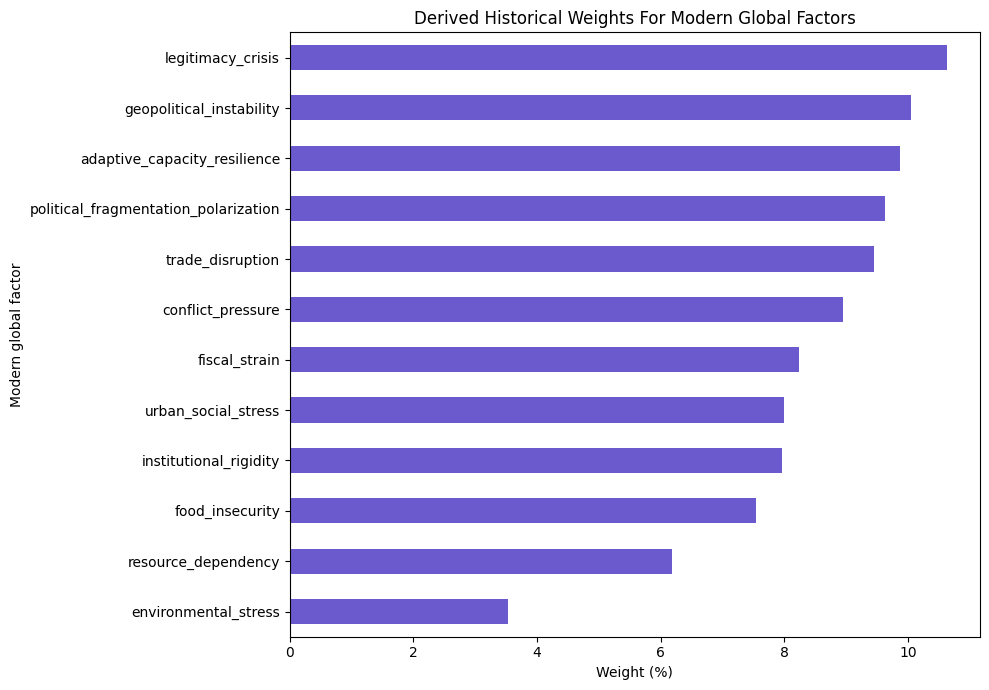

In [4]:
# Historical signals reused from notebooks 09, 10, and 11.
group_a_mask = df["collapse_outcome"].isin([0, 1])
group_b_mask = df["collapse_outcome"].isin([2, 3])
terminal_mask = df["collapse_outcome"].eq(3)

factor_comparison = pd.DataFrame(
    {
        "group_a_mean": known_factor_data.loc[group_a_mask].mean(),
        "group_b_mean": known_factor_data.loc[group_b_mask].mean(),
    }
)
factor_comparison["score_difference"] = factor_comparison["group_b_mean"] - factor_comparison["group_a_mean"]

factor_terminal = pd.DataFrame(
    {
        "mean_outcome_3": known_factor_data.loc[terminal_mask].mean(),
    }
)

factor_uncertainty = pd.DataFrame(
    {
        "unknown_prop": factor_data.eq(9).sum() / len(df),
        "known_n": known_factor_data.notna().sum(),
    }
)

signal_table = factor_comparison.join(factor_terminal).join(factor_uncertainty)

positive_diff_max = signal_table["score_difference"].clip(lower=0).max()
negative_diff_max = (-signal_table["score_difference"].clip(upper=0)).max()

mapping_table = {
    "political_fragmentation_polarization": ["political_fragmentation", "elite_conflict"],
    "legitimacy_crisis": ["legitimacy_crisis"],
    "fiscal_strain": ["fiscal_crisis", "taxation_extraction_pressure"],
    "trade_disruption": ["trade_disruption"],
    "geopolitical_instability": ["territorial_loss", "external_invasion_pressure"],
    "conflict_pressure": ["military_overstretch", "civil_war_internal_conflict"],
    "food_insecurity": ["food_insecurity", "agricultural_decline"],
    "institutional_rigidity": ["institutional_rigidity", "administrative_overload"],
    "urban_social_stress": ["urban_decline", "social_unrest_rebellion", "social_inequality"],
    "resource_dependency": ["resource_dependency"],
    "environmental_stress": ["drought_climate_stress", "flood_environmental_shock", "temperature_anomaly", "ecological_degradation"],
    "adaptive_capacity_resilience": ["adaptive_capacity", "logistics_food_storage_resilience", "alliance_network_strength", "recovery_capacity"],
}

weight_records = []
for row in selected_global_factors.itertuples(index=False):
    mapped = mapping_table[row.factor_name]
    sub = signal_table.loc[mapped]

    if row.role == "stress":
        difference_signal = sub["score_difference"].clip(lower=0).mean() / positive_diff_max if positive_diff_max else 0
        terminal_signal = (sub["mean_outcome_3"] / 3).mean()
    else:
        difference_signal = (-sub["score_difference"].clip(upper=0)).mean() / negative_diff_max if negative_diff_max else 0
        terminal_signal = (1 - (sub["mean_outcome_3"] / 3)).mean()

    coverage_signal = (1 - sub["unknown_prop"]).mean()
    raw_weight = 0.45 * difference_signal + 0.35 * terminal_signal + 0.20 * coverage_signal

    weight_records.append(
        {
            "factor_name": row.factor_name,
            "role": row.role,
            "mapped_historical_factors": ", ".join(mapped),
            "difference_signal": difference_signal,
            "terminal_signal": terminal_signal,
            "coverage_signal": coverage_signal,
            "raw_weight": raw_weight,
        }
    )

weight_table = pd.DataFrame(weight_records)
weight_table["historical_weight"] = weight_table["raw_weight"] / weight_table["raw_weight"].sum()
weight_table["historical_weight_pct"] = weight_table["historical_weight"] * 100
weight_table = weight_table.sort_values("historical_weight", ascending=False)

display(weight_table[[
    "factor_name",
    "role",
    "mapped_historical_factors",
    "difference_signal",
    "terminal_signal",
    "coverage_signal",
    "historical_weight",
    "historical_weight_pct",
]].round(3))

fig, ax = plt.subplots(figsize=(10, 7))
weight_table.iloc[::-1].plot(kind="barh", x="factor_name", y="historical_weight_pct", ax=ax, color="slateblue", legend=False)
ax.set_title("Derived Historical Weights For Modern Global Factors")
ax.set_xlabel("Weight (%)")
ax.set_ylabel("Modern global factor")
plt.tight_layout()
plt.show()

## Part 3 — Manual Present-Day Scoring Template

This is intentionally a blank scoring sheet. The notebook does **not** fetch or invent present-day global scores.

In [5]:
manual_scoring_template = weight_table[["factor_name", "role", "historical_weight"]].copy()
manual_scoring_template["current_global_score_0_to_3"] = pd.NA
manual_scoring_template["weighted_score"] = pd.NA
manual_scoring_template["evidence_notes"] = ""
manual_scoring_template["confidence_level"] = ""
manual_scoring_template = manual_scoring_template[[
    "factor_name",
    "role",
    "historical_weight",
    "current_global_score_0_to_3",
    "weighted_score",
    "evidence_notes",
    "confidence_level",
]]

display(manual_scoring_template)

,factor_name,role,historical_weight,current_global_score_0_to_3,weighted_score,evidence_notes,confidence_level
1,legitimacy_crisis,stress,0.106313,<NA>,<NA>,,
4,geopolitical_instability,stress,0.100526,<NA>,<NA>,,
11,adaptive_capacity_resilience,resilience,0.098742,<NA>,<NA>,,
0,political_fragmentation_polarization,stress,0.096189,<NA>,<NA>,,
3,trade_disruption,stress,0.094495,<NA>,<NA>,,
5,conflict_pressure,stress,0.089513,<NA>,<NA>,,
2,fiscal_strain,stress,0.082360,<NA>,<NA>,,
8,urban_social_stress,stress,0.079924,<NA>,<NA>,,
7,institutional_rigidity,stress,0.079556,<NA>,<NA>,,
6,food_insecurity,stress,0.075357,<NA>,<NA>,,


## Part 4 — Index Formula

A simple and transparent scoring rule is used here.

For any factor score `s` on the 0 to 3 scale:

- stress contribution = `weight * (s / 3)`
- resilience contribution = `weight * (s / 3)`

Then:

1. **Global Stress Score** = weighted average of stress-factor scores, normalized to 0–100
2. **Global Resilience Score** = weighted average of resilience-factor scores, normalized to 0–100
3. **Net Global Fragility Score** = weighted average of:
   - stress-factor intensity, plus
   - resilience shortfall = `1 - (resilience score / 3)`
4. **Normalized Overlap Score** = the Net Global Fragility Score on a 0–100 scale

This means higher resilience lowers the index, while higher stress raises it.

In [6]:
stress_weights = weight_table.loc[weight_table["role"] == "stress", "historical_weight"].sum()
resilience_weights = weight_table.loc[weight_table["role"] == "resilience", "historical_weight"].sum()

formula_table = pd.DataFrame(
    {
        "metric": [
            "Global Stress Score",
            "Global Resilience Score",
            "Net Global Fragility Score",
            "Normalized Overlap Score",
        ],
        "formula": [
            "100 * sum(weight_i * (score_i / 3) for stress factors) / sum(stress weights)",
            "100 * sum(weight_i * (score_i / 3) for resilience factors) / sum(resilience weights)",
            "100 * sum(weight_i * adjusted_score_i) / sum(all weights), where adjusted_score_i = score_i/3 for stress and 1 - score_i/3 for resilience",
            "Same as Net Global Fragility Score, reported on a 0 to 100 scale",
        ],
    }
)

display(formula_table)

display(Markdown(f"**Weight totals**: stress weights = `{stress_weights:.3f}`, resilience weights = `{resilience_weights:.3f}`."))

,metric,formula
0,Global Stress Score,100 * sum(weight_i * (score_i / 3) for stress ...
1,Global Resilience Score,100 * sum(weight_i * (score_i / 3) for resilie...
2,Net Global Fragility Score,100 * sum(weight_i * adjusted_score_i) / sum(a...
3,Normalized Overlap Score,"Same as Net Global Fragility Score, reported o..."


**Weight totals**: stress weights = `0.901`, resilience weights = `0.099`.

## Part 5 — Interpretation Framework

In [7]:
interpretation_scale = pd.DataFrame(
    {
        "score_range": ["0-20", "21-40", "41-60", "61-80", "81-100"],
        "interpretation": [
            "Low overlap with historically recurrent collapse-stress patterns",
            "Mild fragility / limited overlap",
            "Moderate fragility / meaningful pattern overlap",
            "High fragility / strong overlap with historical stress patterns",
            "Severe systemic stress / very strong overlap with historical fragility patterns",
        ],
    }
)

display(interpretation_scale)

interpretation_md = """
**Important**: these ranges describe overlap with historical fragility patterns, not literal collapse probability and not a forecast.
"""
display(Markdown(interpretation_md))

,score_range,interpretation
0,0-20,Low overlap with historically recurrent collap...
1,21-40,Mild fragility / limited overlap
2,41-60,Moderate fragility / meaningful pattern overlap
3,61-80,High fragility / strong overlap with historica...
4,81-100,Severe systemic stress / very strong overlap w...



**Important**: these ranges describe overlap with historical fragility patterns, not literal collapse probability and not a forecast.


## Part 6 — What This Index Can Support

In [8]:
can_support_md = """
### What this index can support

- A structured, historically grounded way to manually compare present-day global conditions with recurrent collapse-related stress patterns.
- Transparent weighting that favors historically stronger and better-supported factors.
- A cautious discussion tool for overlap, fragility, and resilience rather than an automated prediction engine.
- A reporting framework that keeps uncertainty, evidence notes, and confidence judgments visible.
"""
display(Markdown(can_support_md))


### What this index can support

- A structured, historically grounded way to manually compare present-day global conditions with recurrent collapse-related stress patterns.
- Transparent weighting that favors historically stronger and better-supported factors.
- A cautious discussion tool for overlap, fragility, and resilience rather than an automated prediction engine.
- A reporting framework that keeps uncertainty, evidence notes, and confidence judgments visible.


## What This Index Cannot Support

In [9]:
cannot_support_md = """
### What this index cannot support

- A prediction of imminent collapse.
- A probability estimate for the future of the world system.
- A substitute for domain expertise, contemporary political analysis, or live empirical data collection.
- Overconfident claims about factors that remain historically uncertain or only weakly observed in the dataset.
"""
display(Markdown(cannot_support_md))


### What this index cannot support

- A prediction of imminent collapse.
- A probability estimate for the future of the world system.
- A substitute for domain expertise, contemporary political analysis, or live empirical data collection.
- Overconfident claims about factors that remain historically uncertain or only weakly observed in the dataset.


## How To Use This Notebook With Current News Or Indicators

In [10]:
usage_md = """
### How to use this notebook with current news or indicators

1. Start with the blank manual scoring template rather than filling scores impulsively from headlines.
2. For each factor, write short evidence notes from current indicators, reports, or carefully selected news summaries.
3. Assign a `current_global_score_0_to_3` only after comparing the evidence to the historical meaning of the mapped factor.
4. Record a confidence level for each manual score so weak or mixed evidence remains visible.
5. Calculate weighted scores only after the evidence notes are complete.
6. Interpret the final result as a pattern-overlap index: it shows how strongly current conditions resemble historically recurrent fragility patterns, not whether collapse is "coming".
7. Revisit the scores periodically and revise them only when the evidence changes, keeping a dated audit trail if you turn this into a repeated-monitoring workflow.
"""
display(Markdown(usage_md))


### How to use this notebook with current news or indicators

1. Start with the blank manual scoring template rather than filling scores impulsively from headlines.
2. For each factor, write short evidence notes from current indicators, reports, or carefully selected news summaries.
3. Assign a `current_global_score_0_to_3` only after comparing the evidence to the historical meaning of the mapped factor.
4. Record a confidence level for each manual score so weak or mixed evidence remains visible.
5. Calculate weighted scores only after the evidence notes are complete.
6. Interpret the final result as a pattern-overlap index: it shows how strongly current conditions resemble historically recurrent fragility patterns, not whether collapse is "coming".
7. Revisit the scores periodically and revise them only when the evidence changes, keeping a dated audit trail if you turn this into a repeated-monitoring workflow.
